In [1]:
include("src/main.jl")
include("src/plotting.jl")

plot_g2 (generic function with 1 method)

In [2]:
PyPlot.matplotlib[:rc]("text", usetex=true)
PyPlot.matplotlib[:rc]("font", family="serif", size = 18)#serif=["mathpazo"], size=18)  # Base font size
PyPlot.matplotlib[:rc]("axes", titlesize=30)             # Axis title
PyPlot.matplotlib[:rc]("axes", labelsize=30)             # Axis labels
PyPlot.matplotlib[:rc]("xtick", labelsize=24)            # X-ticks
PyPlot.matplotlib[:rc]("ytick", labelsize=24)            # Y-ticks
PyPlot.matplotlib[:rc]("legend", fontsize=24)            # Legend
PyPlot.matplotlib[:rc]("figure", titlesize=24)           # Figure title
PyPlot.svg(true)
# LaTeX preamble packages
PyPlot.matplotlib[:rc]("text.latex", preamble="\\usepackage{amsmath}\\usepackage{amsfonts}\\usepackage{amssymb}\\usepackage{lmodern}")

In [14]:
# Params

g = 15
ω₀ = 15
Δc = -100
κ = 10
temp = 10.0
N = 100
tspan = (0,1)
N_MC = 30

30

In [15]:
V = 0 # Ising strength between dressed atoms
rthresh = 0; #0.1*π # cutoff distance for chi

sqrt.(-1 * (κ^2 + Δc^2) / (2 * Δc) / N) * sqrt.(g)

dressed_idx = collect(1:N); # Does nothing for now

p = System_p(g, ω₀, Δc, κ, temp, N, tspan, N_MC, V, rthresh, dressed_idx)

sim = many_trajectory_solver(p, saveat=0.01);

done in 12.700362 seconds.


In [72]:
g_new = 1.2*g;
Δc_new =  Δc
V_new = 0.35*g_new;
rthresh = 0.1*π;
p_new  = System_p(g_new, ω₀, Δc, κ, temp, N, tspan, N_MC, V_new, rthresh, dressed_idx);
deltat = 1;

quench = quench_prob(extract_solution(sim), p_new, deltat)

sim_q =  solve(quench, SOSRA2(), EnsembleThreads(), trajectories=p.N_MC, saveat=0.01, progress=true)

EnsembleSolution Solution of length 30 with uType:
RODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, NoiseProcess{Float64, 2, Float64, Vector{Float64}, Vector{Float64}, Vector{Vector{Float64}}, typeof(DiffEqNoiseProcess.INPLACE_WHITE_NOISE_DIST), typeof(DiffEqNoiseProcess.INPLACE_WHITE_NOISE_BRIDGE), Nothing, true, ResettableStacks.ResettableStack{Tuple{Float64, Vector{Float64}, Vector{Float64}}, true}, ResettableStacks.ResettableStack{Tuple{Float64, Vector{Float64}, Vector{Float64}}, true}, RSWM{Float64}, Nothing, RandomNumbers.Xorshifts.Xoroshiro128Plus}, Nothing, SDEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, System_p, Nothing, SDEFunction{true, SciMLBase.FullSpecialize, typeof(f_det), typeof(f_noise), UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing, Nothing}, typeof(f_noise), Base.Pairs{Symbol, Union{}, Tuple{},

In [72]:
extract_solution(sim_q)[1].p

System_p(20.0, 15.0, -100.0, 10.0, 10.0, 100, (0.0, 2.0), 30, 12.0, 0.3141592653589793, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  91, 92, 93, 94, 95, 96, 97, 98, 99, 100], [1.5482771661616468, 4.418461529402332, 0.005788348696952994, 0.021999689282520052, 6.270358094944228, 0.8526941519665119, 3.2546192361505017, 3.7911469327023326, 3.4174827424531085, 5.431008019898385  …  6.213254941622317, 3.538706798881595, 0.7671965109229504, 2.559090875818537, 1.6290738273560308, 5.883844842296671, 3.678447390401887, 0.06942517827849315, 5.31327257893173, 2.983015671654904], [184.32380629878566, 189.51761312484277, 300.9366852435222, 319.2099151159742, 279.54777815052654, 155.86570813266013, 277.2704446656776, 245.27410201544623, 347.09550442239237, 434.62526907931533  …  239.36287704017604, 362.9728290406959, 135.1530405895477, 369.98891257382456, 209.3252014209773, 121.50237439672512, 364.86143991938246, 255.35225297311314, 516.0184205770212, 275.06812808854284])

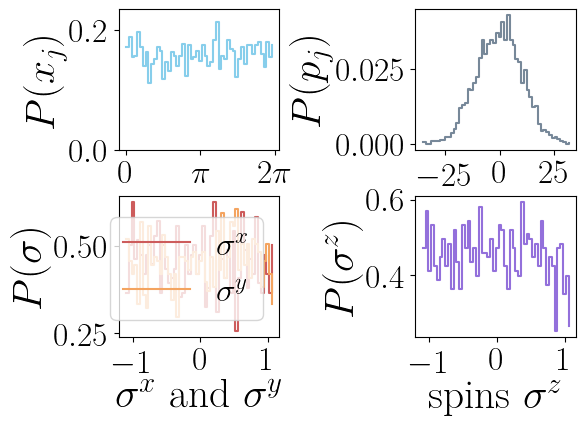

In [47]:
fig, ax = plot_initial_conditions(extract_solution(sim_q))
display(fig)

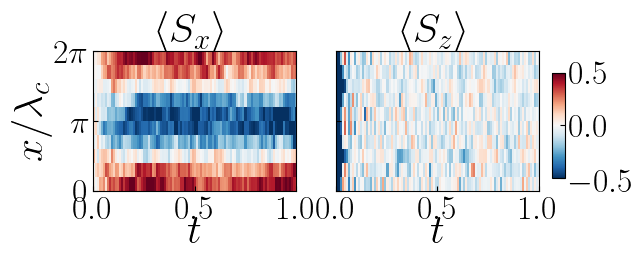

(Figure(PyObject <Figure size 637.5x300 with 3 Axes>), ([0.04854368932038835 -0.015265074590892817 … 0.39452126131514365 0.3692677220680098; -0.009009009009009009 0.0987922572263724 … 0.47551857005528053 0.4547167728337973; … ; 0.014925373134328358 0.007258419490175659 … 0.26132048719036555 0.2855252408893207; 0.023255813953488372 0.026143706443798955 … 0.3218904643744049 0.3522557247608582], [-1.0 -1.0095220024996228 … -0.05740639958600166 0.009245828862107744; -1.0 -0.9960652238351434 … -0.08498022508855672 -0.08240375814138147; … ; -1.0 -0.9613787213051628 … -0.1261171886924934 -0.0916147354670577; -1.0 -0.8436763633561466 … 0.006640468398184133 -0.04574143286163629], [103 109 … 126 118; 111 115 … 110 106; … ; 134 147 … 119 113; 129 117 … 136 139], [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09  …  0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0], [0.3141592653589793, 0.9424777960769379, 1.5707963267948966, 2.199114857512855, 2.827433388230814, 3.45575191894877

In [57]:
plus, minus, _ = categorize_traj(extract_solution(sim))
plot_spinspositionhisto(plus)

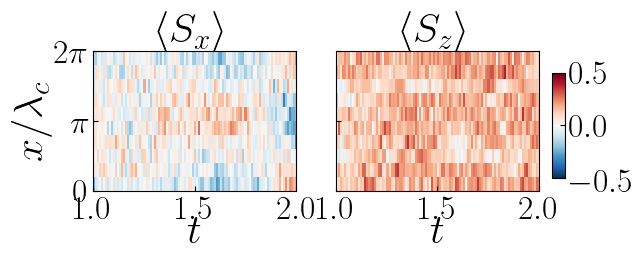

(Figure(PyObject <Figure size 637.5x300 with 3 Axes>), ([-0.2333674196531986 -0.09787893054544215 … 0.14982051501605065 0.17209354525049297; 0.04461468762235746 0.05060240427437526 … 0.06768504173239619 0.05772704338928801; … ; -0.08834337867685589 0.0923548905586859 … 0.1328168104848521 0.1408093087145648; -0.12317118470004015 -0.15968297761402545 … 0.11876298391178332 0.22843911667462738], [-0.03886438097961667 0.09498248268076696 … 0.2722221508480209 0.24649972847709378; -0.0984383894711015 0.20363889674557778 … 0.15956143670646447 0.07680167550514892; … ; -0.17565706654278326 0.15783617725780266 … 0.08754154412395673 0.08056195614162069; -0.07227655548788675 0.14859671981670292 … 0.07801666560932707 0.1207159325542552], [226 208 … 207 204; 174 192 … 193 199; … ; 223 195 … 212 197; 204 221 … 210 215], [1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09  …  1.91, 1.92, 1.93, 1.94, 1.95, 1.96, 1.97, 1.98, 1.99, 2.0], [0.3141592653589793, 0.9424777960769379, 1.5707963267948966, 

In [74]:
plus, minus, _ = categorize_traj(extract_solution(sim_q))
plot_spinspositionhisto(plus)

In [75]:
sim_T = merge_sim(extract_solution(sim), extract_solution(sim_q));

mean_adaga, std_adaga, q90_adaga = expect(obs_adaga, sim);
q90_adaga = hcat(q90_adaga...);

p_X2, _, q90_pX2 = expect(obs_X, plus);
q90_pX2 = hcat(q90_pX2...);

m_X2, _, q90_mX2 = expect(obs_X, minus);
q90_mX2 = hcat(q90_mX2...);

p_Jz, _, q90_Jz = expect(obs_Jz, plus);
q90_Jz = hcat(q90_Jz...);

m_Jz, _, q90_mJz = expect(obs_Jz, minus);
q90_mJz = hcat(q90_mJz...);

m_Bp, _, q90_Bp = expect(obs_Cos2, plus);
q90_Bp = hcat(q90_Bp...);

m_Bm, _, q90_Bm = expect(obs_Cos2, minus);
q90_Bm = hcat(q90_Bm...);

m_Cosp, _, q90_Cosp = expect(obs_Cos, plus);
q90_Cosp = hcat(q90_Cosp...);

m_Cosm, _, q90_Cosm = expect(obs_Cos, minus);
q90_Cosm = hcat(q90_Cosm...);

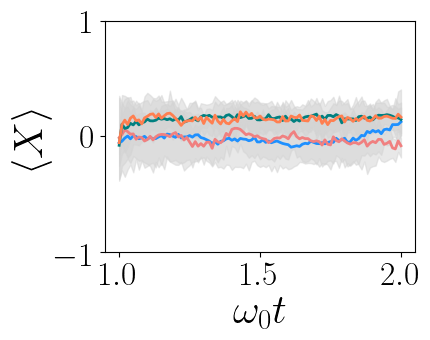

In [76]:
fig, ax = subplots(figsize=(4,3))
ax.plot(sim_q[1].t, p_X2, lw=2, color="dodgerblue")
ax.fill_between(sim_q[1].t, q90_pX2[1,:], q90_pX2[2,:], color="lightgray", alpha=0.5)
ax.plot(sim_q[1].t, m_X2, lw=2, color="lightcoral")
ax.fill_between(sim_q[1].t, q90_mX2[1,:], q90_mX2[2,:], color="lightgray", alpha=0.5)
ax.plot(sim_q[1].t, p_Jz, lw=2, color="teal")
ax.fill_between(sim_q[1].t, q90_Jz[1,:], q90_Jz[2,:], color="lightgray", alpha=0.5)
ax.plot(sim_q[1].t, m_Jz, lw=2, color="coral")
ax.fill_between(sim_q[1].t, q90_mJz[1,:], q90_mJz[2,:], color="lightgray", alpha=0.5)
# ax.plot(sim[1].t, m_Cosp, lw=2, color="purple")
# ax.fill_between(sim[1].t, q90_Cosp[1,:], q90_Cosp[2,:], color="lightgray", alpha=0.5)
# ax.plot(sim[1].t, m_Cosm, lw=2, color="orange")
# ax.fill_between(sim[1].t, q90_Cosm[1,:], q90_Cosm[2,:], color="lightgray", alpha=0.5)
ax.set_yticks([-1,0,1])
ax.set_ylabel(L"\langle X\rangle")
ax.set_xlabel(L"\omega_0t")
display(fig)

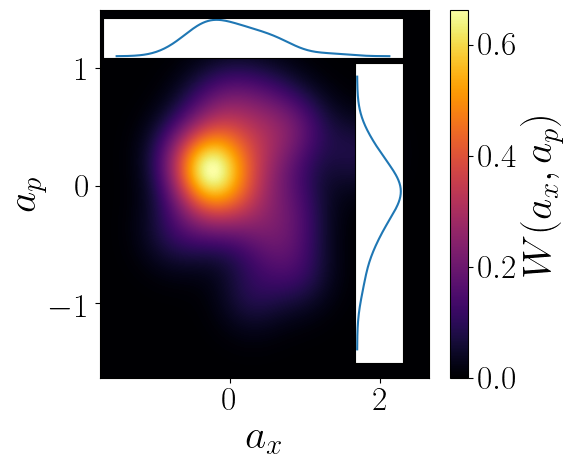

In [24]:
plot_cavity_wigner(sim_q, time_idx=95, show_contours=false)

sys:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


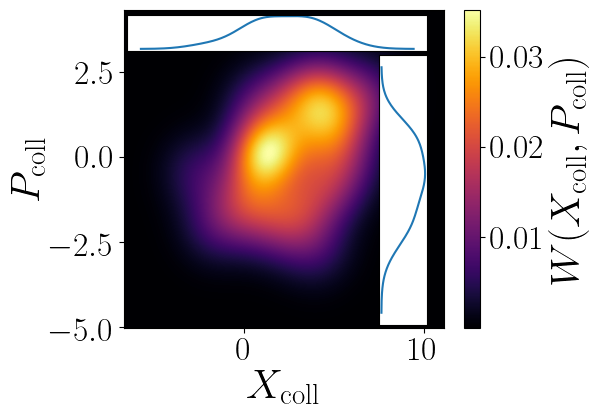

In [33]:
plot_collective_wigner(sim, time_idx=199)

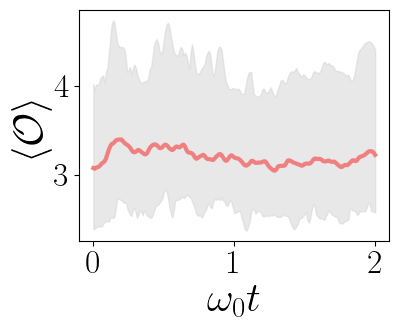

In [209]:
# Define cavity phase via qudrature expectation values 

a_xm, _, a_xq = expect(obs_ar, plus);
a_pm, _, a_pq = expect(obs_ai, plus);

kurtm, _, kurtq = expect(obs_kurt, plus);
Ekinm, _, Ekinq = expect(obs_Ekin, plus);


a_xq = hcat(a_xq...);
a_pq = hcat(a_pq...);
kurtq = hcat(kurtq...);
Ekinq = hcat(Ekinq...);

fig, ax =  subplots(figsize=(4,3))
# ax.plot(sim[1].t, a_xm, lw=3, color="purple")
# ax.fill_between(sim[1].t, a_xq[1,:], a_xq[2,:], color="lavender", alpha=0.5)
# ax.plot(sim[1].t, a_pm, lw=3, color="palevioletred")
# ax.fill_between(sim[1].t, a_pq[1,:], a_pq[2,:], color="pink", alpha=0.5)
ax.plot(sim[1].t, kurtm, lw=3, color="lightcoral")
ax.fill_between(sim[1].t, kurtq[1,:], kurtq[2,:], color="lightgray", alpha=0.5)
# ax.plot(sim[1].t, Ekinm, lw=3, color="dodgerblue")
# ax.fill_between(sim[1].t, Ekinq[1,:], Ekinq[2,:], color="lightgray", alpha=0.5)
ax.set_ylabel(L"\langle \mathcal{O}\rangle")
ax.set_xlabel(L"\omega_0t")
display(fig)

Cavity field squeezing

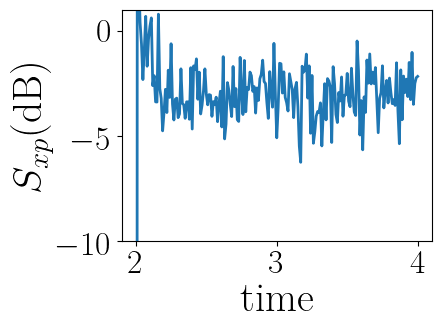

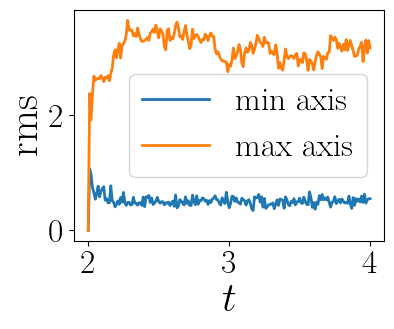

In [203]:
# --- 2) Observables for X^2, P^2 and symmetric XP
obs_ar2 = Observable(
    (sol, params) -> begin
        N = sol.p.N

        return [ (sol.u[5N + 1, j])^2 for j = 1:length(sol.t) ]
    end,
    "X2", "⟨X^2⟩"
)

obs_ai2 = Observable(
    (sol, params) -> begin
        N = sol.p.N

        return [ (sol.u[5N + 2, j])^2 for j = 1:length(sol.t) ]
    end,
    "P2", "⟨P^2⟩"
)

obs_ri_sym = Observable(
    (sol, params) -> begin
        N = sol.p.N
        return [ 0.5*(sol.u[5N + 1,j]*sol.u[5N + 2,j] + sol.u[5N + 2,j]*sol.u[5N + 1,j])
                 for j = 1:length(sol.t) ]
    end,
    "XPsym", "0.5*⟨XP+PX⟩"
)

# --- 3) Pull expectations from the simulator (match your expect signature)
# Your earlier pattern returned three values; adapt destructuring if needed.
X_mean, _, _   = expect(obs_ar, sim)   # ⟨X⟩(t)
P_mean, _, _   = expect(obs_ai, sim)   # ⟨P⟩(t)
X2_mean, _, _  = expect(obs_ar2, sim)   # ⟨X^2⟩(t)
P2_mean, _, _  = expect(obs_ai2, sim)   # ⟨P^2⟩(t)
XP_mean, _, _  = expect(obs_ri_sym, sim)# 0.5⟨XP+PX⟩(t)

# time vector (adjust depending on sim object)
t = sim_q[1].t    # or sim[1].t as in your code

# --- 4) Covariance matrix elements
VarX = X2_mean .- X_mean.^2
VarP = P2_mean .- P_mean.^2
CovXP = XP_mean .- X_mean .* P_mean

# Numerical safety: clip tiny negative values due to roundoff
tol = 1e-14
VarX = max.(VarX, tol)
VarP = max.(VarP, tol)

# --- 5) Diagonalize at each time to get principal variances & angle
nt = length(t)
lam_min = zeros(nt)
lam_max = zeros(nt)
theta   = zeros(nt)  # angle of squeezed quadrature relative to X axis (radians)

for i in 1:nt
    V = Symmetric([VarX[i] CovXP[i]; CovXP[i] VarP[i]])
    evals, evecs = eigen(V)         # evals ascending
    lam_min[i] = evals[1]
    lam_max[i] = evals[2]
    # angle from eigenvector (vector for lam_min at column 1)
    v = evecs[:,1]
    theta[i] = atan(v[2], v[1])     # atan(y,x) gives angle of eigenvector
    # alternatively use half-angle formula:
    # theta[i] = 0.5 * atan( 2*CovXP[i] / (VarX[i] - VarP[i]) )
end

# --- 6) Convert to dB relative to vacuum variance
V_vac = 0.5   # change if your quadrature normalization differs
squeeze_dB = 10 .* log10.(lam_min ./ V_vac)

# --- 7) Plot results (example)
fig, ax = subplots(figsize=(4,3))
ax.plot(t, squeeze_dB, lw=2)
ax.set_xlabel("time")
ax.set_ylabel(L"$S_{xp}$(dB)")
ax.set_ylim(-10,1)
display(fig)

# Optional: plot rms (sqrt of variances) of principal axes
fig2, ax2 = subplots(figsize=(4,3))
ax2.plot(t, sqrt.(lam_min), lw=2, label="min axis")
ax2.plot(t, sqrt.(lam_max), lw=2, label="max axis")
ax2.set_ylabel("rms")
ax2.set_xlabel(L"t")
ax2.legend()
display(fig2)

Correlators

In [207]:
function product_observable(oA::Observable, oB::Observable; short_name="A*B", formula="A*B")
    Observable(
        (sol, params) -> begin
            A = oA.s_traj(sol, params) 
            B = oB.s_traj(sol, params)
            return A .* B
        end,
        formula,
        short_name
    )
end

obs_AB = product_observable(obs_adaga, obs_Jz)
meanAB, stdAB, q = expect(obs_AB, plus)    # returns mean ⟨AB⟩, etc (matches your expect signature)
meanA, stdA, _    = expect(obs_X, plus)
meanB, stdB, _    = expect(obs_Z, plus)

connected = meanAB .- meanA .* meanB;

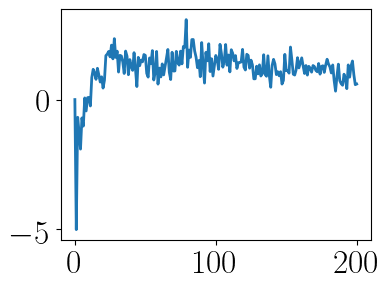

In [208]:
fig, ax = subplots(figsize=(4,3))
ax.plot(meanAB, lw=2)
display(fig)